# Projeto Aplicado III - Etapa 4

Notebook simples para documentar os passos do sistema de recomendação de receitas.

## 1. Bibliotecas

In [1]:
import ast
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import NearestNeighbors

## 2. Caminhos dos dados

Os arquivos devem estar na pasta `data` do repositório. No ambiente desta entrega, também foi usado `/mnt/data` para rodar os testes.

In [2]:
def achar_pasta_dados():
    opcoes = [Path('data'), Path('../data'), Path('/mnt/data')]
    for pasta in opcoes:
        if (pasta / 'RAW_recipes.csv').exists():
            return pasta
    return Path('data')

pasta_dados = achar_pasta_dados()
pasta_dados

WindowsPath('data')

## 3. Carregamento dos dados

In [3]:
qtd_receitas = 50000

receitas = pd.read_csv(pasta_dados / 'RAW_recipes.csv', nrows=qtd_receitas)
treino = pd.read_csv(pasta_dados / 'interactions_train.csv')
validacao = pd.read_csv(pasta_dados / 'interactions_validation.csv')
teste = pd.read_csv(pasta_dados / 'interactions_test.csv')

receitas.shape, treino.shape, validacao.shape, teste.shape

((50000, 12), (698901, 6), (7023, 6), (12455, 6))

## 4. Análise exploratória simples

In [4]:
print('Receitas carregadas:', receitas['id'].nunique())
print('Usuários no treino:', treino['user_id'].nunique())
print('Interações de treino:', len(treino))
print('Média das notas no treino:', round(treino['rating'].mean(), 4))
print('Mediana das notas no treino:', treino['rating'].median())

Receitas carregadas: 50000
Usuários no treino: 25076
Interações de treino: 698901
Média das notas no treino: 4.5741
Mediana das notas no treino: 5.0


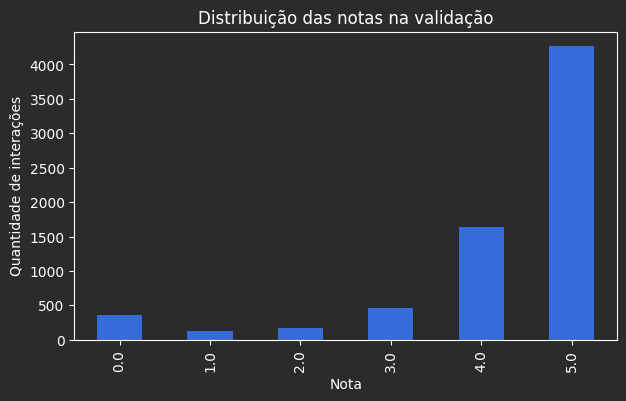

In [6]:
validacao['rating'].value_counts().sort_index().plot(kind='bar', figsize=(7,4), title='Distribuição das notas na validação')
plt.xlabel('Nota')
plt.ylabel('Quantidade de interações')
plt.show()

## 5. Preparação das receitas

In [7]:
def texto_para_lista(valor):
    if pd.isna(valor):
        return []
    try:
        lista = ast.literal_eval(valor)
        if isinstance(lista, list):
            return [str(x).lower().strip() for x in lista]
    except Exception:
        return []
    return []

receitas_modelo = receitas.copy()
receitas_modelo = receitas_modelo.drop_duplicates(subset='id')
receitas_modelo = receitas_modelo.dropna(subset=['id', 'name'])
receitas_modelo = receitas_modelo[receitas_modelo['minutes'].fillna(0) > 0].copy()

limite_tempo = receitas_modelo['minutes'].quantile(0.99)
receitas_modelo['tempo_tratado'] = receitas_modelo['minutes'].clip(upper=limite_tempo)

receitas_modelo['ingredientes_lista'] = receitas_modelo['ingredients'].apply(texto_para_lista)
receitas_modelo['tags_lista'] = receitas_modelo['tags'].apply(texto_para_lista)

receitas_modelo['texto_receita'] = (
    receitas_modelo['name'].fillna('') + ' ' +
    receitas_modelo['ingredientes_lista'].apply(lambda x: ' '.join(x)) + ' ' +
    receitas_modelo['tags_lista'].apply(lambda x: ' '.join(x))
)

receitas_modelo = receitas_modelo.reset_index(drop=True)
receitas_modelo[['id', 'name', 'minutes', 'n_ingredients']].head()

,id,name,minutes,n_ingredients
0,137739,arriba baked winter squash mexican style,55,7
1,31490,a bit different breakfast pizza,30,6
2,112140,all in the kitchen chili,130,13
3,59389,alouette potatoes,45,11
4,44061,amish tomato ketchup for canning,190,8


## 6. Treinamento do recomendador baseado em conteúdo

In [9]:
vetorizador = TfidfVectorizer(stop_words='english', min_df=2, max_df=0.90, max_features=15000)
matriz_receitas = vetorizador.fit_transform(receitas_modelo['texto_receita'])

modelo_vizinhos = NearestNeighbors(metric='cosine', algorithm='brute')
modelo_vizinhos.fit(matriz_receitas)

matriz_receitas.shape

(49748, 5901)

## 7. Função para recomendar receitas parecidas

In [10]:
def recomendar_por_receita(id_receita, quantidade=10):
    posicoes = pd.Series(receitas_modelo.index, index=receitas_modelo['id']).to_dict()
    if id_receita not in posicoes:
        return pd.DataFrame()

    posicao = posicoes[id_receita]
    distancias, indices = modelo_vizinhos.kneighbors(matriz_receitas[posicao], n_neighbors=quantidade + 1)
    recomendacoes = receitas_modelo.iloc[indices.flatten()].copy()
    recomendacoes['similaridade'] = 1 - distancias.flatten()
    recomendacoes = recomendacoes[recomendacoes['id'] != id_receita]
    return recomendacoes[['id', 'name', 'minutes', 'n_ingredients', 'similaridade']].head(quantidade)

id_exemplo = int(receitas_modelo.iloc[0]['id'])
recomendar_por_receita(id_exemplo, quantidade=5)

,id,name,minutes,n_ingredients,similaridade
15445,254360,baked winter squash,40,5,0.619077
15446,272858,baked winter squash au gratin,70,9,0.520240
30258,439069,brown sugar glazed winter squash,75,5,0.508367
15142,261048,baked spaghetti squash,50,4,0.476662
40660,168161,cheesy summer squash spears,35,7,0.460767


## 8. Recomendação por ingredientes digitados

In [11]:
def recomendar_por_ingredientes(ingredientes_digitados, quantidade=10):
    texto = ingredientes_digitados.lower().replace(',', ' ')
    vetor_usuario = vetorizador.transform([texto])
    modelo_busca = NearestNeighbors(metric='cosine', algorithm='brute')
    modelo_busca.fit(matriz_receitas)
    distancias, indices = modelo_busca.kneighbors(vetor_usuario, n_neighbors=quantidade)
    recomendacoes = receitas_modelo.iloc[indices.flatten()].copy()
    recomendacoes['similaridade'] = 1 - distancias.flatten()
    return recomendacoes[['id', 'name', 'minutes', 'n_ingredients', 'similaridade']]

recomendar_por_ingredientes('chicken, rice, tomato', quantidade=10)

,id,name,minutes,n_ingredients,similaridade
45703,430680,chicken taco and rice,30,9,0.541848
14524,484310,baked mexican rice vegetarian,50,8,0.527585
42712,389374,chicken and rice burritos,30,8,0.505628
42738,199858,chicken and rice with bacon,210,10,0.504814
42100,165939,chicken rice that wins the internet,45,8,0.503368
46765,230901,chicken wrapped sausages with mushroom tomato ...,85,16,0.502254
44139,534998,chicken helper chicken enchilada copycat,35,14,0.500499
44953,240916,chicken pesto and rice,40,13,0.499374
26659,107515,bolla s peanut stew,25,12,0.498348
18203,278353,basic chicken rice,105,7,0.494260


## 9. Avaliação das linhas de base

In [12]:
media_geral = treino['rating'].mean()
media_receita = treino.groupby('recipe_id')['rating'].mean()
media_usuario = treino.groupby('user_id')['rating'].mean()

real = validacao['rating']
prev_media_geral = pd.Series(media_geral, index=validacao.index)
prev_receita = validacao['recipe_id'].map(media_receita).fillna(media_geral)
prev_usuario = validacao['user_id'].map(media_usuario).fillna(media_geral)
prev_combinada = (prev_receita + prev_usuario) / 2

resultados = []
for nome, previsto in [
    ('Media geral', prev_media_geral),
    ('Media por receita', prev_receita),
    ('Media por usuario', prev_usuario),
    ('Media usuario + receita', prev_combinada),
]:
    rmse = math.sqrt(mean_squared_error(real, previsto))
    mae = mean_absolute_error(real, previsto)
    resultados.append({'modelo': nome, 'RMSE': rmse, 'MAE': mae})

resultado_metricas = pd.DataFrame(resultados)
resultado_metricas

,modelo,RMSE,MAE
0,Media geral,1.346776,0.858343
1,Media por receita,1.346776,0.858343
2,Media por usuario,1.290494,0.796193
3,Media usuario + receita,1.277964,0.811911


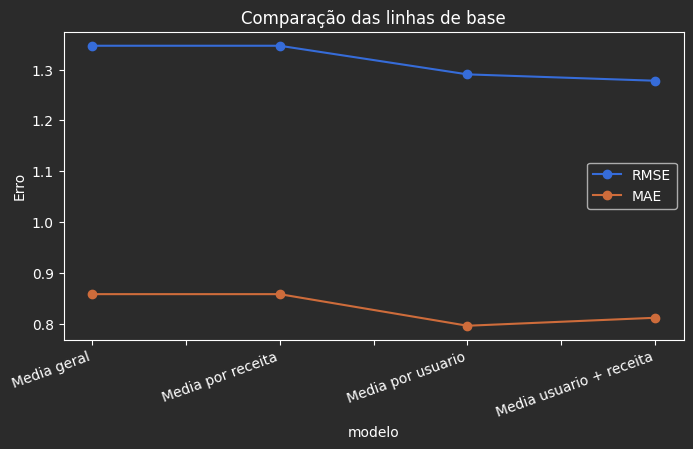

In [13]:
resultado_metricas.plot(x='modelo', y=['RMSE', 'MAE'], marker='o', figsize=(8,4), title='Comparação das linhas de base')
plt.xticks(rotation=20, ha='right')
plt.ylabel('Erro')
plt.show()

## 10. Avaliação Top-K simples

Receitas com nota maior ou igual a 4 foram consideradas relevantes. O resultado foi baixo na amostra, principalmente pela alta esparsidade dos dados.

In [14]:
def avaliar_popularidade(treino, validacao, k=10, max_usuarios=500):
    relevantes_validacao = validacao[validacao['rating'] >= 4]
    usuarios = relevantes_validacao['user_id'].drop_duplicates().head(max_usuarios)

    receitas_populares = (
        treino[treino['rating'] >= 4]
        .groupby('recipe_id')
        .size()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    precisions = []
    recalls = []

    for usuario in usuarios:
        vistos = set(treino.loc[treino['user_id'] == usuario, 'recipe_id'])
        reais = set(relevantes_validacao.loc[relevantes_validacao['user_id'] == usuario, 'recipe_id'])
        recomendados = [r for r in receitas_populares if r not in vistos][:k]
        acertos = len(set(recomendados) & reais)
        precisions.append(acertos / k)
        recalls.append(acertos / len(reais) if len(reais) > 0 else 0)

    return pd.DataFrame([{
        'modelo': 'Popularidade',
        'Precision@10': np.mean(precisions),
        'Recall@10': np.mean(recalls),
        'usuarios_avaliados': len(precisions)
    }])

avaliacao_topk = avaliar_popularidade(treino, validacao)
avaliacao_topk

,modelo,Precision@10,Recall@10,usuarios_avaliados
0,Popularidade,0.0,0.0,500


## 11. Conclusão dos resultados

O modelo baseado em conteúdo consegue gerar recomendações coerentes por similaridade de ingredientes e tags. As métricas Top-K ficaram baixas na avaliação offline, o que mostra uma limitação da base e da técnica simples utilizada. Como trabalho futuro, recomenda-se evoluir para um modelo híbrido com mais interações, fator temporal dos ingredientes e validação com usuários reais.